# RGT-Est Demo

This notebook runs the pretrained RGT-Est model on a 3D seismic volume without any horizon constraints — the two auxiliary input channels are filled with zeros. The model returns a dense relative geological time (RGT) volume; horizons are then traced from RGT iso-surfaces and rendered together with the seismic in 2D sections and in two linked viser canvases.

本 notebook 在一个 3D 地震体上运行预训练的 RGT-Est 模型，不使用任何层位约束——两个辅助输入通道置零。模型输出一个稠密的相对地质时间（RGT）体；随后从 RGT 等值面追踪层位，并与地震一同在 2D 剖面和两个相机同步的 viser 画布中显示。

## 1. Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import cigvis
from cigvis import viserplot
from cigvis import colormap
from cigvis.viserplot import create_server, link_servers

from rgt_helper import horizons_from_rgt, horizon_image

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cuda


## 2. Preprocessing helpers

`normalization` performs min-max scaling to `[0, 1]`. `z_score_clip` standardizes the data, clips to ±`clp_s`σ, and then min-max scales the result. The clip step suppresses outliers before normalization so they do not compress the useful dynamic range.

`normalization` 将数据线性映射到 `[0, 1]`。`z_score_clip` 先做标准化，再按 ±`clp_s`σ 截断，最后做 min-max 归一化。截断步骤抑制极值，避免它们压缩有效动态范围。

In [2]:
def normalization(data: np.ndarray) -> np.ndarray:
    rng = np.max(data) - np.min(data)
    return (data - np.min(data)) / (rng + 1e-6)


def z_score_clip(data: np.ndarray, clp_s: float = 3.0) -> np.ndarray:
    z = (data - np.mean(data)) / (np.std(data) + 1e-8)
    return normalization(np.clip(z, a_min=-clp_s, a_max=clp_s))

## 3. Load seismic

The seismic volume is z-score clipped at ±2σ, rescaled to `[-1, 1]`, and transposed to `(H, W, T)` for downstream tools.

地震体在 ±2σ 处做 z-score 截断，缩放到 `[-1, 1]`，并转置为 `(H, W, T)`。

In [4]:
seis = np.load(r'../RealData/Poseidon_part1.npy').astype(np.float32)
seis = z_score_clip(seis, clp_s=2).transpose(1, 2, 0) * 2 - 1
h, w, t = seis.shape
print('seis shape (H, W, T):', seis.shape)

seis shape (H, W, T): (576, 256, 272)


## 4. RGT inference

The seismic is trilinearly resampled to the inference grid `(400, 512, 512)` and stacked with two zero channels to match the model's three-channel input convention (the second and third channels would normally carry horizon RGT values and a labelled-voxel mask). Replication padding of 8 voxels is applied on every side before the forward pass and trimmed afterwards to avoid edge artefacts.

将地震体三线性重采样到推理网格 `(400, 512, 512)`，并与两个零通道拼接以满足模型的三通道输入约定（第二、第三通道在带约束时分别承载层位 RGT 数值与标注体素 mask）。前向之前对每个面做 8 体素的复制填充，推理后再裁掉，避免边界伪影。

<span style="color:red">⚠️ The inference size must be (400, 512, 512), otherwise it will affect performance or cause inference failure. For other sizes or arbitrary size support, please contact us at xinmwu@ustc.edu.cn && douyimin@ustc.edu.cn</span>

<span style="color:red">**⚠️ 推理尺寸必须是（400, 512, 512），否则影响性能或导致推理失败，更多其他尺寸或需任意尺寸联系我们 xinmwu@ustc.edu.cn && douyimin@ustc.edu.cn**</span>

In [5]:
model = torch.jit.load('../pretrianedModel/RGT-Est_CIG-Benchmark.pt').to(device)
model.eval()

infer_shape = (400, 512, 512)
# 必须是该尺寸，否则影响性能或导致推理失败，更多其他尺寸联系我们xinmwu@ustc.edu.cn && douyimin@ustc.edu.cn
#It must be this size, otherwise it will affect performance or cause inference failure. For more other infer-sizes, please contact us xinmwu@ustc.edu.cn  &&  douyimin@ustc.edu.cn

seis_tensor = torch.from_numpy(seis.transpose(2, 0, 1))[None, None]
seis_tensor = F.interpolate(seis_tensor, infer_shape, mode='trilinear')

input_tensor = torch.cat(
    [seis_tensor, torch.zeros_like(seis_tensor), torch.zeros_like(seis_tensor)],
    dim=1,
).to(device)

with torch.no_grad():
    with torch.autocast(device_type=device):
        padded = nn.ReplicationPad3d(8)(input_tensor)
        rgt = model(padded)[:, :, 8:-8, 8:-8, 8:-8]

print('RGT raw output shape:', tuple(rgt.shape))

RGT raw output shape: (1, 1, 400, 512, 512)


## 5. Resample RGT back to the original grid

The model output is trilinearly interpolated back to the original `(t, h, w)` grid and z-score normalized so that subsequent contour levels and color scales are stable across runs.

将模型输出三线性插值回原始 `(t, h, w)` 网格，并做 z-score 归一化，使后续的等值线水平和色标在不同运行间保持稳定。

In [6]:
rgt_volume = F.interpolate(rgt.float(), (t, h, w), mode='trilinear').cpu().numpy()[0, 0]
rgt_volume = z_score_clip(rgt_volume)
print('rgt_volume shape (T, H, W):', rgt_volume.shape)

rgt_volume shape (T, H, W): (272, 576, 256)


## 6. Trace horizons from the RGT volume

Horizons are extracted as iso-surfaces of the RGT volume. `horizons_from_rgt` returns horizon surfaces; `horizon_image` rasterizes them into a 0/1 mask thickened by `d` voxels. Multiplying the mask by the RGT volume preserves the RGT value on each horizon, which is used both for the 3D overlay color and the 2D contour color in later sections.

层位以 RGT 体的等值面形式提取。`horizons_from_rgt` 返回层位曲面，`horizon_image` 将其光栅化为厚度为 `d` 体素的 0/1 mask。将该 mask 与 RGT 体相乘后，每条层位上保留其原始 RGT 数值，这一数值随后既用于三维叠加配色，也用于二维等值线着色。

In [7]:
ux = rgt_volume.transpose(1, 2, 0)            # (H, W, T)
n3, n2, n1 = ux.shape

hu = np.linspace(0.00, 1, 100)

hzs = horizons_from_rgt(sig=1.0, hu=hu, ux=ux)

rgt_mask = horizon_image(n1=n1, n2=n2, n3=n3, d=3, sig=0.0, x1=hzs)
rgt_mask = (rgt_mask > 0).astype(np.float32) * ux
print('rgt_mask shape (H, W, T):', rgt_mask.shape)

rgt_mask shape (H, W, T): (576, 256, 272)


## 7. 2D slice preview

Four evenly-spaced sections are drawn along the inline (axis 0) and xline (axis 1) directions. Each row shows the seismic in grayscale, the predicted RGT in `jet`, and the seismic with horizon iso-contours overlaid. The contour lines are colored by their RGT value with the same `jet` colormap and shared color limits, so a given color denotes the same relative geological time across every panel.

沿 inline（第 0 轴）和 xline（第 1 轴）方向分别均匀抽取 4 条剖面。每行依次显示灰度地震、`jet` 配色的预测 RGT、以及叠加层位等值线的地震。等值线按其 RGT 值使用同一个 `jet` 配色和共享色标着色，因此同一颜色在所有剖面上代表同一相对地质时间。

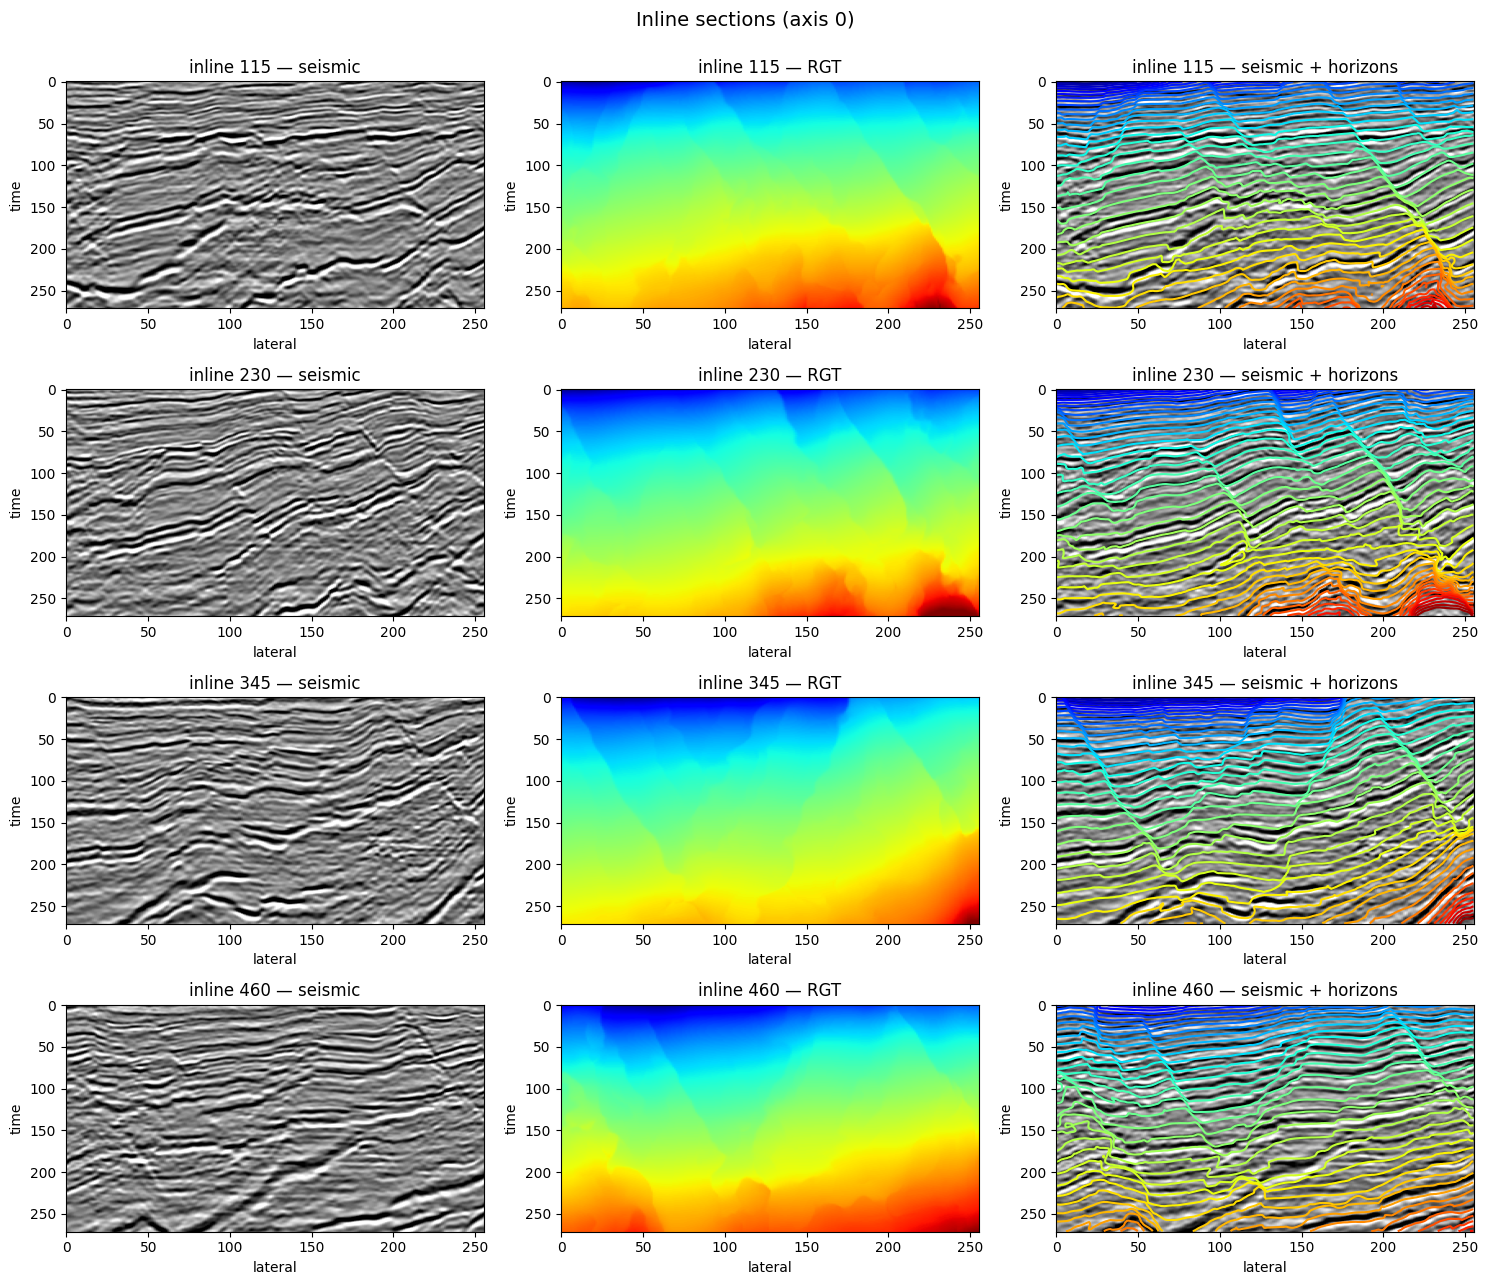

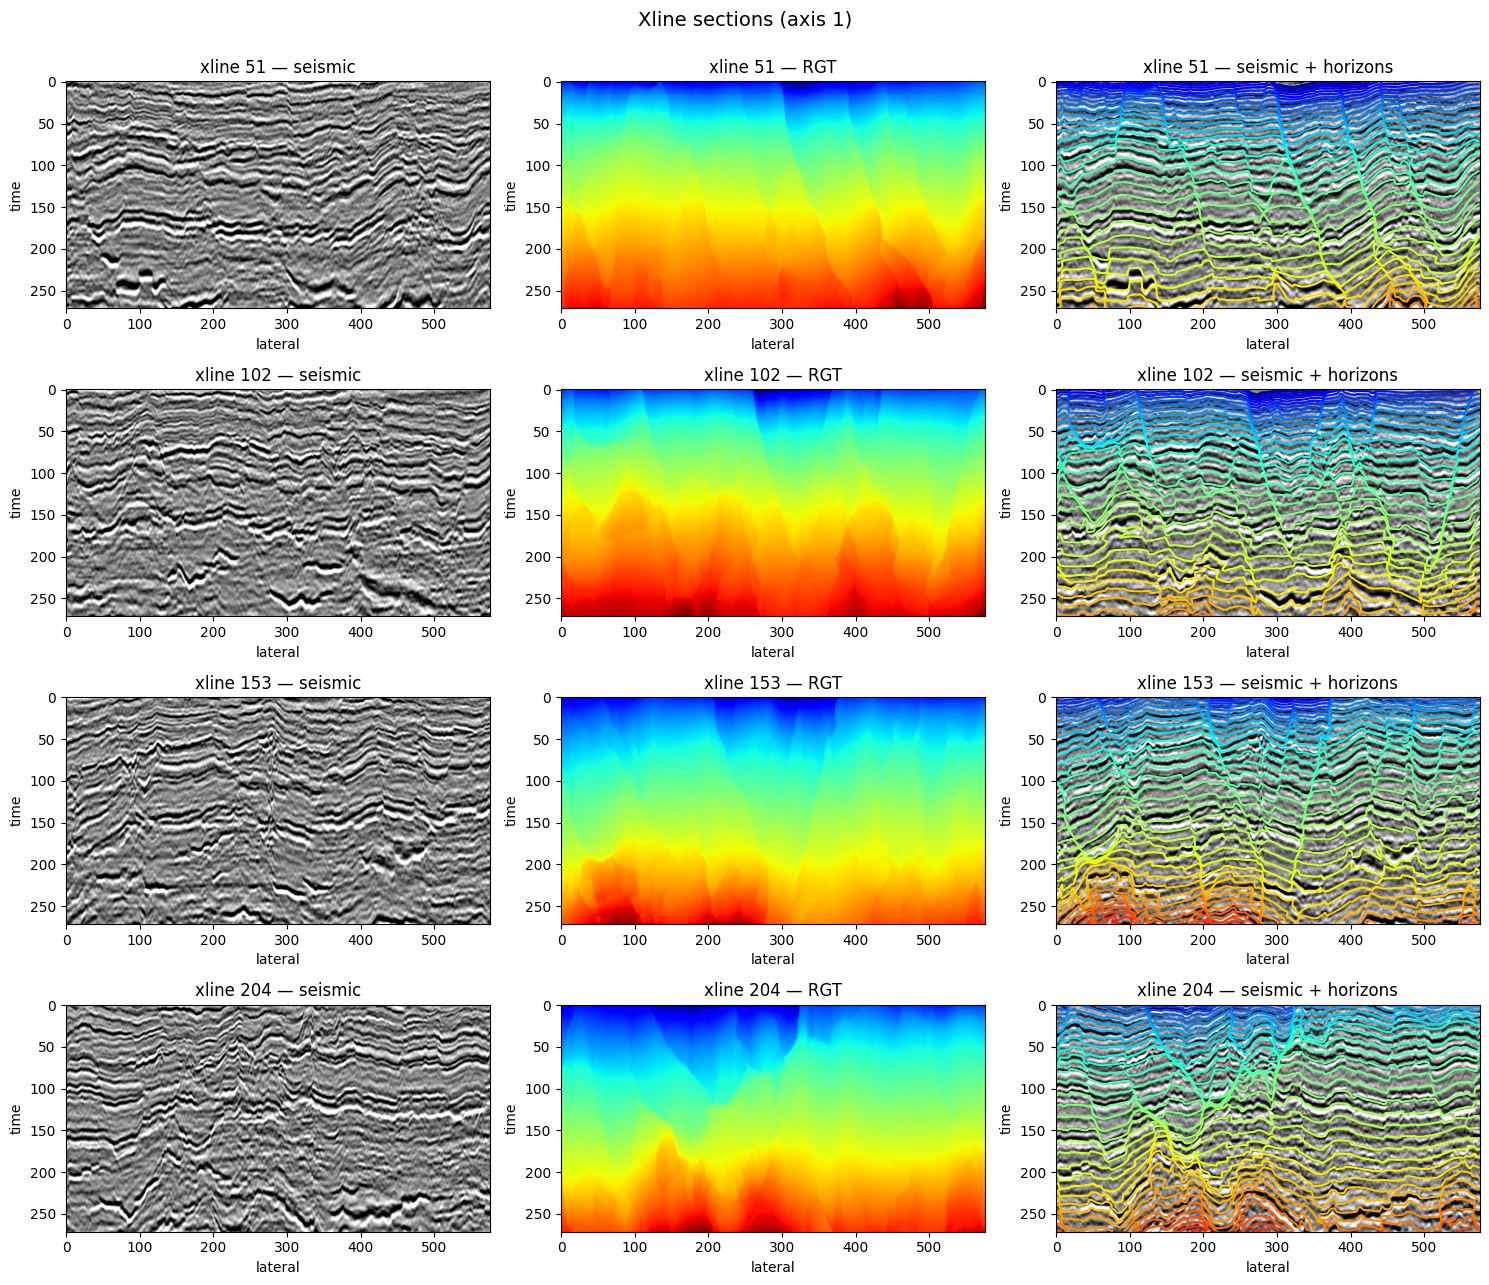

In [8]:
import matplotlib.pyplot as plt

# seis / rgt_volume layouts:
#   seis       : (H, W, T)  = (n_iline, n_xline, n_t)
#   rgt_volume : (T, H, W)
rgt_hwt = rgt_volume.transpose(1, 2, 0)        # → (H, W, T) to match seis
n_il, n_xl, n_t = seis.shape

# Contour levels = iso-values of the RGT volume, same idea as the 3D `hu` list.
n_levels = 45
levels   = np.linspace(rgt_hwt.min() + 0.02, rgt_hwt.max() - 0.02, n_levels)

def _plot_section(seis_sec, rgt_sec, title_prefix, axes_row):
    # seis_sec / rgt_sec are (T, X) — time on the vertical axis, lateral on horizontal.
    vmax_s = np.percentile(np.abs(seis_sec), 99)
    ax_s, ax_r, ax_o = axes_row

    ax_s.imshow(seis_sec, cmap='gray', aspect='auto', vmin=-vmax_s, vmax=vmax_s)
    ax_s.set_title(f'{title_prefix} — seismic')

    ax_r.imshow(rgt_sec, cmap='jet', aspect='auto')
    ax_r.set_title(f'{title_prefix} — RGT')

    ax_o.imshow(seis_sec, cmap='gray', aspect='auto', vmin=-vmax_s, vmax=vmax_s)
    ax_o.contour(rgt_sec, levels=levels, cmap='jet',
                 vmin=float(rgt_hwt.min()), vmax=float(rgt_hwt.max()),
                 linewidths=1.5)
    ax_o.set_title(f'{title_prefix} — seismic + horizons')

    for ax in axes_row:
        ax.set_xlabel('lateral'); ax.set_ylabel('time')

# ---- inline direction (axis 0 of seis) ----
il_idx = np.linspace(0, n_il - 1, 4 + 2, dtype=int)[1:-1]   # 4 evenly-spaced, skip edges
fig, axes = plt.subplots(len(il_idx), 3, figsize=(15, 3.2 * len(il_idx)))
for row, i in enumerate(il_idx):
    seis_sec = seis[i, :, :].T              # (T, n_xline)
    rgt_sec  = rgt_hwt[i, :, :].T           # (T, n_xline)
    _plot_section(seis_sec, rgt_sec, f'inline {i}', axes[row])
fig.suptitle('Inline sections (axis 0)', fontsize=14, y=1.0)
fig.tight_layout()
plt.show()

# ---- xline direction (axis 1 of seis) ----
xl_idx = np.linspace(0, n_xl - 1, 4 + 2, dtype=int)[1:-1]
fig, axes = plt.subplots(len(xl_idx), 3, figsize=(15, 3.2 * len(xl_idx)))
for row, j in enumerate(xl_idx):
    seis_sec = seis[:, j, :].T              # (T, n_iline)
    rgt_sec  = rgt_hwt[:, j, :].T           # (T, n_iline)
    _plot_section(seis_sec, rgt_sec, f'xline {j}', axes[row])
fig.suptitle('Xline sections (axis 1)', fontsize=14, y=1.0)
fig.tight_layout()
plt.show()

## 8. Linked 3D viewers

Two viser canvases are launched: one shows the seismic alone in grayscale, the other shows the seismic with the horizon mask overlaid in the `AI` colormap (zero values made transparent). Camera transforms and per-axis slice positions are mirrored between the two canvases so that any view change in one is reflected in the other.

启动两个 viser 画布：一个仅以灰度显示地震，另一个在地震之上叠加用 `AI` 配色的层位 mask（零值透明）。两个画布之间镜像同步相机位姿和按轴切片位置——任一画布的视角变化都会同步到另一个。

In [17]:
seis_disp = seis
fg_cmap   = colormap.set_alpha_except_min('AI', alpha=1)

# ---- 1) build two servers ----
server_seis    = viserplot.create_server(8080)
server_overlay = viserplot.create_server(8081)

# ---- 2) build nodes (keep references for slice sync) ----
nodes_seis = viserplot.create_slices(seis_disp, cmap='gray')
viserplot.plot3D(nodes_seis, server=server_seis)

nodes_overlay = viserplot.create_slices(seis_disp, cmap='gray')
viserplot.add_mask(nodes_overlay, rgt_mask, cmaps=fg_cmap, interpolation='nearest')
viserplot.plot3D(nodes_overlay, server=server_overlay)

# ---- 3) extract the three VolumeSlice nodes (one per axis) on each server ----
from cigvis.visernodes import VolumeSlice

def _slice_map(nodes):
    """{axis: VolumeSlice}"""
    return {n.axis: n for n in nodes if isinstance(n, VolumeSlice)}

slices_a = _slice_map(nodes_seis)
slices_b = _slice_map(nodes_overlay)

# ---- 4) slice-position sync via monkey-patching update_node ----
_slice_syncing = {'on': False}

def _wrap(node, peers_by_axis):
    """When this node updates, push the same pos to its peer on the other server."""
    orig = node.update_node
    def patched(pos):
        orig(pos)
        if _slice_syncing['on']:
            return
        peer = peers_by_axis.get(node.axis)
        if peer is None or peer.pos == node.pos:
            return
        _slice_syncing['on'] = True
        try:
            peer.update_node(node.pos)
        finally:
            _slice_syncing['on'] = False
    node.update_node = patched

for ax, n in slices_a.items():
    _wrap(n, slices_b)
for ax, n in slices_b.items():
    _wrap(n, slices_a)

# ---- 5) camera sync (same as before) ----
ALL_SERVERS = [server_seis, server_overlay]
_cam_syncing = {'on': False}

def _attach_cam(src):
    @src.on_client_connect
    def _(client):
        @client.camera.on_update
        def _(_cam):
            if _cam_syncing['on']:
                return
            _cam_syncing['on'] = True
            try:
                pos, wxyz = client.camera.position, client.camera.wxyz
                look, fov = client.camera.look_at, client.camera.fov
                for s in ALL_SERVERS:
                    if s is src:
                        continue
                    for c in s.get_clients().values():
                        c.camera.position = pos
                        c.camera.wxyz     = wxyz
                        c.camera.look_at  = look
                        c.camera.fov      = fov
            finally:
                _cam_syncing['on'] = False

for s in ALL_SERVERS:
    _attach_cam(s)

print('camera + slice sync ready; (re)load iframes to take effect')

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

camera + slice sync ready; (re)load iframes to take effect


## 9. Embed both views in the notebook

Each viser canvas is embedded as an iframe so the two views can be inspected side-by-side without leaving the notebook.

将每个 viser 画布以 iframe 嵌入，使两个视图能在 notebook 内并排查看。

In [8]:
from IPython.display import HTML

host   = 'localhost'
ports  = [8080, 8081]
titles = ['Seismic', 'Seismic + Horizons']

frames = '\n'.join(
    f'''
    <div style="width:100%;">
      <div style="text-align:center; font-weight:bold; padding:4px;">{title}</div>
      <iframe src="http://{host}:{p}" width="100%" height="700"
              style="border:1px solid #ccc;" allowfullscreen></iframe>
    </div>
    '''
    for p, title in zip(ports, titles)
)

HTML(f'<div style="display:flex; flex-direction:column; gap:12px; width:100%;">{frames}</div>')